<a href="https://www.kaggle.com/code/nahuelfuentes/vaca-muerta-oil-gas-production-analysis?scriptVersionId=319484874" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Vaca muerta: Oil & Gas Production Analysis
---
**Author:** Nahuel Ignacio Fuentes
**Data Source:** datos.energia.gob.ar  
**Period:** 2006-2026  
**Goal:** Analyze production trends across Neuquén basin wells

## Why This Dataset?

This is a **real-world dataset** provided by Argentina's Secretary of Energy 
(datos.energia.gob.ar) that records monthly production reports submitted by 
oil and gas companies operating across the country.

## Useful fact about the dataset:

- Mandatory reporting : Companies are legally required to submit monthly production data for every active well
- Well-level granularity : Each row represents one well's monthly production, giving detailed insight into field performance
- Long time series : Data spans from 2006 to present, capturing major industry shifts like the Vaca Muerta shale boom


## What we can learn from it:
- Where are the mayority of deposits?
- Which companies are exploiting each resource?
- How much oil, gas and water are produced in each deposit?
- Which is deposit has given the most product?
- Which deposit are declining in resources?

For this we use multiple interactive views for filtering between companies, deposits and resources.

In [38]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy.optimize import curve_fit
import ipywidgets as widgets
from IPython.display import display, HTML


# For keeping the interactive display on commited version
import plotly.io as pio
pio.renderers.default = 'iframe'

Import dataset using pandas

In [2]:
# Dataset provided by datos.energia.gob.ar
url = "http://datos.energia.gob.ar/dataset/c846e79c-026c-4040-897f-1ad3543b407c/resource/b5b58cdc-9e07-41f9-b392-fb9ec68b0725/download/produccin-de-pozos-de-gas-y-petrleo-no-convencional.csv"

# Load dataframe
df = pd.read_csv(url)
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400759 entries, 0 to 400758
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               400759 non-null  object 
 1   anio                    400759 non-null  int64  
 2   mes                     400759 non-null  int64  
 3   idpozo                  400759 non-null  int64  
 4   prod_pet                400759 non-null  float64
 5   prod_gas                400759 non-null  float64
 6   prod_agua               400759 non-null  float64
 7   iny_agua                400759 non-null  float64
 8   iny_gas                 400759 non-null  float64
 9   iny_co2                 400759 non-null  float64
 10  iny_otro                400759 non-null  float64
 11  tef                     400759 non-null  float64
 12  vida_util               8468 non-null    float64
 13  tipoextraccion          400158 non-null  object 
 14  tipoestado          

# Filter dataset 

## Row example

In [3]:
print(df.iloc[0])

idempresa                                          YSUR
anio                                               2018
mes                                                   1
idpozo                                           132771
prod_pet                                          7.212
prod_gas                                        510.173
prod_agua                                          0.34
iny_agua                                            0.0
iny_gas                                             0.0
iny_co2                                             0.0
iny_otro                                            0.0
tef                                               30.15
vida_util                                           NaN
tipoextraccion                        Surgencia Natural
tipoestado                          Extracción Efectiva
tipopozo                                       Gasífero
observaciones                                       NaN
fechaingreso                 2018-02-10 08:37:14

## Dropping columns

Rename columns for easy usage in map viewing

In [4]:
df.rename(columns={
    "coordenaday":"lat",
    "coordenadax":"lon"
}, inplace=True)

Only choose those related to the cuenca neuquina and drop columns that we won't be using

In [6]:
df_neuquina = df[df['cuenca'] == 'NEUQUINA']
df_neuquina = df_neuquina.drop(columns=['iny_agua','iny_gas','iny_otro','iny_co2','tef',
                               'observaciones','rectificado','habilitado','idusuario','sigla','formprod',
                               'idareapermisoconcesion','areapermisoconcesion','sub_tipo_recurso'])

## Handling unique and null values

See if the value 'vida_util' is usable because of null values and if there is more than one type of resource

In [7]:

print('Percentage of rows with null "vida_util" values : ', (df_neuquina['vida_util'].isnull().sum() / df_neuquina.shape[0]) * 100,'%')
print('Possible resource type are :',df_neuquina['tipo_de_recurso'].unique())

Percentage of rows with null "vida_util" values :  97.92952480982514 %
Possible resource type are : ['NO CONVENCIONAL']


It's not usable for the sheer amount of null values in relationship to the number of rows, also we could drop resource type as it's only one possible

In [8]:
df_neuquina = df_neuquina.drop(columns=['vida_util','tipo_de_recurso'])

# Views

## Location based oil well

In [9]:
df_oil_wells = df_neuquina[["idpozo","areayacimiento","lat","lon","prod_pet","prod_gas","prod_agua"]].drop_duplicates(subset="idpozo")

df_oil_wells["hover_pet"] = df_oil_wells["areayacimiento"]+' '+df_oil_wells['idpozo'].astype(str) + "<br>Oil production: " + df_oil_wells["prod_pet"].astype(str)+"m³"
df_oil_wells["hover_gas"] = df_oil_wells["areayacimiento"]+' '+df_oil_wells['idpozo'].astype(str) +"<br>Gas production: " + df_oil_wells["prod_gas"].astype(str)+"Mm³"
df_oil_wells["hover_water"] = df_oil_wells["areayacimiento"]+' '+df_oil_wells['idpozo'].astype(str) +"<br>Water production: " + df_oil_wells["prod_agua"].astype(str)+"m³"

first_year = sorted(df_neuquina['anio'].unique())[0]
last_year = sorted(df_neuquina['anio'].unique())[-1]

In [10]:
fig = go.Figure()

fig.add_trace(
    go.Scattermapbox(
        name='Oil',
        lat=df_oil_wells["lat"],
        lon=df_oil_wells["lon"],
        mode="markers",
        visible=True,
        marker=go.scattermapbox.Marker(
            showscale=True,
            color=df_oil_wells["prod_pet"],
            size=df_oil_wells["prod_pet"],
            sizemode="area",                    # "area" or "diameter"
            sizeref=2 * df_oil_wells["prod_pet"].max() / (20**2),  # controls scale
            sizemin=3                           # minimum marker size
        ),
        text=df_oil_wells["hover_pet"],
        hoverinfo="text"
    )
)
fig.add_trace(
    go.Scattermapbox(
        name='Gas',
        lat=df_oil_wells["lat"],
        lon=df_oil_wells["lon"],
        mode="markers",
        visible=False,
        marker=go.scattermapbox.Marker(
            showscale=True,
            color=df_oil_wells["prod_gas"],
            size=df_oil_wells["prod_gas"],
            sizemode="area",                    # "area" or "diameter"
            sizeref=2 * df_oil_wells["prod_gas"].max() / (20**2),  # controls scale
            sizemin=2                           # minimum marker size
        ),
        text=df_oil_wells["hover_gas"],
        hoverinfo="text"
    )
)

fig.add_trace(
    go.Scattermapbox(
        name='Water',
        lat=df_oil_wells["lat"],
        lon=df_oil_wells["lon"],
        mode="markers",
        visible=False,
        marker=go.scattermapbox.Marker(
            showscale=True,
            color=df_oil_wells["prod_agua"],
            colorscale="Blues",
            cmin=df_oil_wells["prod_agua"].quantile(0.20),
            cmax=df_oil_wells["prod_agua"].quantile(0.95),
            size=df_oil_wells["prod_agua"],
            sizemode="area",                    # "area" or "diameter"
            sizeref=2 * df_oil_wells["prod_agua"].max() / (20**2),  # controls scale
            sizemin=3                           # minimum marker size
        ),
        text=df_oil_wells["hover_water"],
        hoverinfo="text"
    )
)

fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(label="Oil",
                     method="update",
                     args=[{"visible": [True, False, False]}]),
                dict(label="Gas",
                     method="update",
                     args=[{"visible": [False, True, False]}]),
                dict(label="Water",
                     method="update",
                     args=[{"visible": [False, False, True]}]),
            ],
            direction="right",
            x=0.01,
            y=0.99,
        )
    ],
    margin={"r":0,"t":50,"l":0,"b":20},
    mapbox_style="carto-positron",
    mapbox_zoom=9,
    mapbox_center={"lat": -38.4, "lon": -68.7},
    title=f"Total production from {first_year}-{last_year}"
)

fig.show()

## Deposit size based on production

Filter dataset by adding all the production on each deposit and normalize values

In [11]:
df_deposits = df_neuquina.groupby("areayacimiento").agg(
    prod_pet=("prod_pet","sum"),
    prod_gas=("prod_gas","sum"),
    prod_agua=("prod_agua","sum"),
    lat=("lat","first"),
    lon=("lon","first")
).reset_index()

# For displaying purposes

# We normalize and scale for a better sizing display
df_deposits["prod_pet_norm"] = (df_deposits["prod_pet"] / df_deposits["prod_pet"].max()) * 100  
df_deposits["prod_gas_norm"] = (df_deposits["prod_gas"] / df_deposits["prod_gas"].max()) * 100  
df_deposits["prod_agua_norm"] = (df_deposits["prod_agua"] / df_deposits["prod_agua"].max()) * 100

# Text on hover
df_deposits["hover_pet"] = df_deposits["areayacimiento"] + "<br>Oil production: " + df_deposits["prod_pet"].astype(str)
df_deposits["hover_gas"] = df_deposits["areayacimiento"] + "<br>Gas production: " + df_deposits["prod_gas"].astype(str)
df_deposits["hover_agua"] = df_deposits["areayacimiento"] + "<br>Water production: " + df_deposits["prod_agua"].astype(str)

Generate view using Plotly Scattermapbox with markers based on color and size

In [12]:
fig = go.Figure()

fig.add_trace(
    go.Scattermapbox(
        name='Oil',
        lat=df_deposits["lat"],
        lon=df_deposits["lon"],
        mode="markers",
        visible=True,
        marker=go.scattermapbox.Marker(
            showscale=True,
            colorscale="Viridis",
            color=df_deposits["prod_pet"],
            size=df_deposits["prod_pet_norm"],
            sizemode="diameter",                   
            sizemin=3                         
        ),
        text=df_deposits["hover_pet"],
        hoverinfo="text"
    )
)
fig.add_trace(
    go.Scattermapbox(
        name='Gas',
        lat=df_deposits["lat"],
        lon=df_deposits["lon"],
        mode="markers",
        visible=False,
        marker=go.scattermapbox.Marker(
            showscale=True,
            colorscale="Viridis",
            color=df_deposits["prod_gas"],
            size=df_deposits["prod_gas_norm"],
            sizemode="diameter",                
            sizemin=3                        
        ),
        text=df_deposits["hover_gas"],
        hoverinfo="text"
    )
)

fig.add_trace(
    go.Scattermapbox(
        name='Water',
        lat=df_deposits["lat"],
        lon=df_deposits["lon"],
        mode="markers",
        visible=False,
        marker=go.scattermapbox.Marker(
            showscale=True,
            colorscale="Blues",
            color=df_deposits["prod_agua"],
            size=df_deposits["prod_agua_norm"],
            sizemode="diameter",                   
            sizemin=3                         
        ),
        text=df_deposits["hover_agua"],
        hoverinfo="text"
    )
)

fig.update_layout(
      updatemenus=[
        dict(
            buttons=[
                dict(label="Oil",
                     method="update",
                     args=[{"visible": [True, False, False]}]),
                dict(label="Gas",
                     method="update",
                     args=[{"visible": [False, True, False]}]),
                dict(label="Water",
                     method="update",
                     args=[{"visible": [False, False, True]}]),
            ],
            direction="right",
            x=0.01,
            y=0.99,
        )
    ],
    margin={"r":0,"t":0,"l":0,"b":0},
    mapbox_style="carto-positron",
    mapbox_zoom=9,
    mapbox_center={"lat": -38.4, "lon": -68.7}
)

fig.show()

## Oil production by company

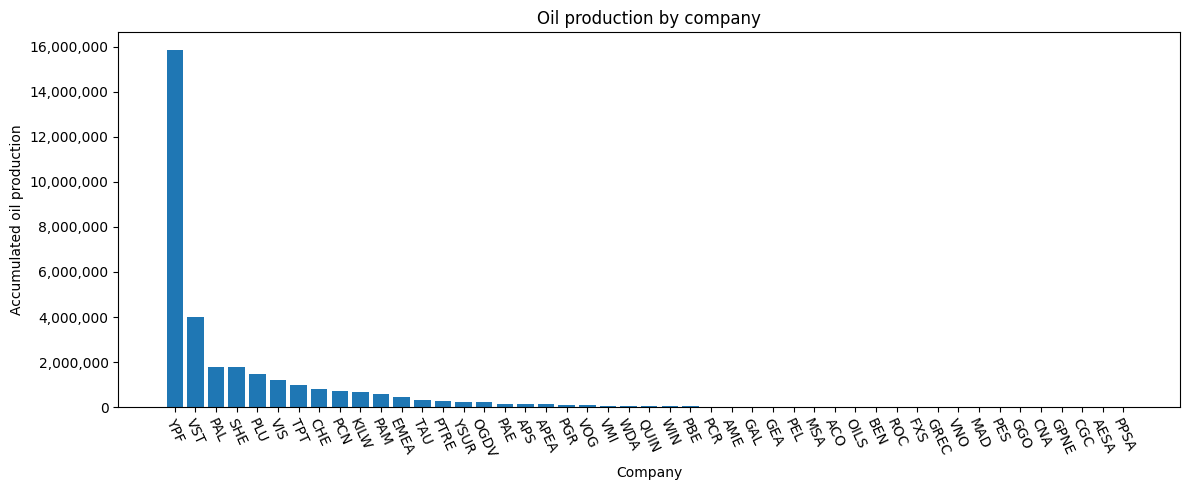

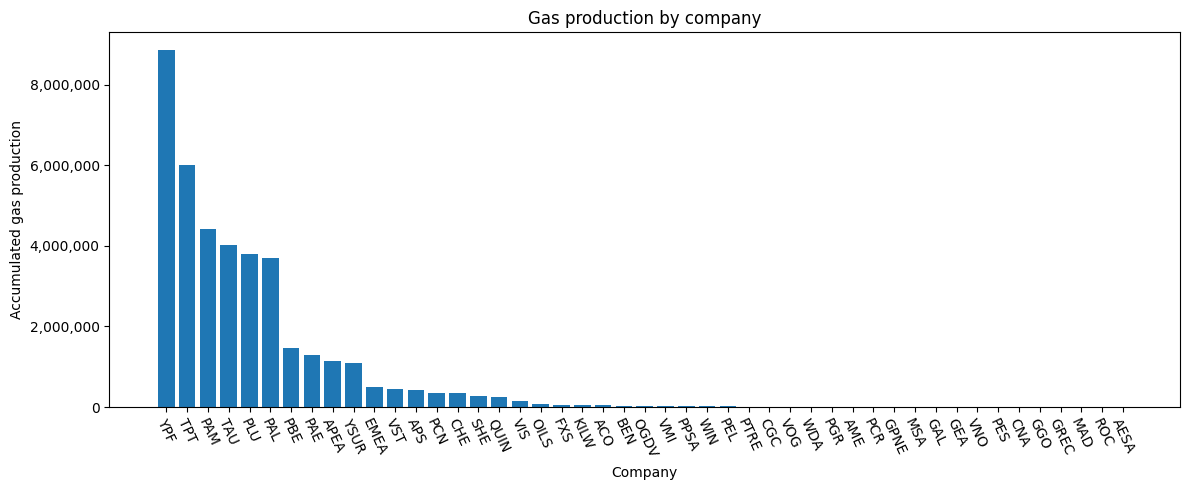

In [13]:
# Accumalted the producted on the table
df_prod_by_company = df_neuquina.groupby(["idempresa","anio"])[list(["prod_pet","prod_gas"])].sum().reset_index()

df_prod_pet_by_company = df_prod_by_company.sort_values(['prod_pet'], ascending=False)
df_prod_gas_by_company = df_prod_by_company.sort_values(['prod_gas'], ascending=False)

# Optional drop company that doesn't produce that resource

df_prod_pet_by_company = df_prod_pet_by_company[df_prod_pet_by_company['prod_pet'] != 0]
df_prod_gas_by_company = df_prod_gas_by_company[df_prod_gas_by_company['prod_gas'] != 0]

# Plot both figures

plt.figure(figsize=(12,5))
plt.bar(df_prod_pet_by_company['idempresa'], df_prod_pet_by_company['prod_pet'])
plt.title("Oil production by company")
plt.xlabel("Company")
plt.xticks(rotation=-65)
plt.ylabel("Accumulated oil production")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.bar(df_prod_gas_by_company['idempresa'], df_prod_gas_by_company['prod_gas'])
plt.title("Gas production by company")
plt.xlabel("Company")
plt.xticks(rotation=-65)
plt.ylabel("Accumulated gas production")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## Filter production type by year

In [14]:
# With plotly
years = sorted(df_prod_by_company['anio'].unique())

fig2 = go.Figure()

# Add traces for each type of production by year
for y in years:
    d = df_prod_by_company[df_prod_by_company["anio"] == y]
    fig2.add_trace(go.Bar(
        x=d.sort_values('prod_pet', ascending=False)['idempresa'],
        y=d.sort_values('prod_pet', ascending=False)['prod_pet'],
        name=f"Petrol {y}", visible=False,
        marker_color = '#2c2c2c'
    ))
    fig2.add_trace(go.Bar(
        x=d.sort_values('prod_gas', ascending=False)['idempresa'],
        y=d.sort_values('prod_gas', ascending=False)['prod_gas'],
        name=f"Gas {y}", visible=False,
        marker_color = '#1f77b4'
    ))

n = len(years)

# Web build one button for each year to choose from
buttons = []
for i, y in enumerate(years):
    for j, (label, offset) in enumerate([("Oil", 0), ("Gas", 1)]):
        vis = [False] * (2 * n)
        vis[2 * i + offset] = True
        yaxis_title = "Production (m³)" if label == "Oil" else "Production (Mm³)"
        buttons.append(
            {"label": f"{label} {y}", "method": "update", "args": [{"visible": vis}, {"yaxis": {"title": yaxis_title}}]}
        )

# Set first trace visible by default
fig2.data[0].visible = True

fig2.update_layout(
    updatemenus=[{
        "buttons": buttons,
        "direction": "down",
        "x": 0.7, "y": 1.2,
        "showactive": True
    }],
    xaxis_title="Company",
    yaxis_title="Production (m³)"
)
fig2.show()

### Widget instead of dash because of kaggle limitations

In [15]:
year_dropdown = widgets.Dropdown(
    options=sorted(df_prod_by_company["anio"].unique()),
    description="Year:"
)

product_dropdown = widgets.Dropdown(
    options=[("Petrol", "prod_pet"), ("Gas", "prod_gas")],
    description="Product:"
)

def update_chart(selected_year, selected_product):
    d = df_prod_by_company[df_prod_by_company["anio"] == selected_year]
    d = d.sort_values(selected_product, ascending=False)
    fig = go.Figure(go.Bar(x=d["idempresa"], y=d[selected_product]))
    fig.update_layout(title=f"Vaca Muerta — {selected_product} {selected_year}")
    fig.show()

widgets.interact(update_chart, selected_year=year_dropdown, selected_product=product_dropdown)

interactive(children=(Dropdown(description='Year:', options=(np.int64(2006), np.int64(2007), np.int64(2008), n…

<function __main__.update_chart(selected_year, selected_product)>

### Production of petrol and oil by company through the years

In [16]:
df_prod_through_years = df_neuquina.groupby(['idempresa','anio'])[list(['prod_pet','prod_gas'])].sum().reset_index()

# Select companies and years
companies = df_neuquina['idempresa'].unique()

colors = px.colors.sample_colorscale("Viridis", len(companies))


fig3 = go.Figure()



for c in companies:
    d = df_prod_through_years[df_prod_through_years['idempresa'] == c ].sort_values('anio')
    
    fig3.add_trace(
        go.Scatter(
            y=d['prod_pet'],
            x=d['anio'],
            name=f"{c}",
            marker_color=colors
        )
    )

first_year = df_prod_through_years.sort_values('anio')['anio'].unique()[0]
last_year = df_prod_through_years.sort_values('anio')['anio'].unique()[-1]

fig3.update_layout(
    xaxis_range=[first_year,last_year],
    title="Oil production through the years",
    margin={"r":50,"t":50,"b":50,"l":50},
    yaxis_title = "Production (m³)",
    xaxis_title = "Years"
)

fig3.show()



In [17]:
df_prod_through_years = df_neuquina.groupby(['idempresa','anio'])[list(['prod_pet','prod_gas'])].sum().reset_index()

# Select companies and years
companies = df_neuquina['idempresa'].unique()

colors = px.colors.sample_colorscale("Viridis", len(companies))


fig3 = go.Figure()



for c in companies:
    d = df_prod_through_years[df_prod_through_years['idempresa'] == c ].sort_values('anio')
    
    fig3.add_trace(
        go.Scatter(
            y=d['prod_gas'],
            x=d['anio'],
            name=f"{c}",
            marker_color=colors
        )
    )


fig3.data[0].visible = True

first_year = df_prod_through_years.sort_values('anio')['anio'].unique()[0]
last_year = df_prod_through_years.sort_values('anio')['anio'].unique()[-1]

fig3.update_layout(
    xaxis_range=[first_year,last_year],
    title="Gas production through the years",
    margin={"r":50,"t":50,"b":50,"l":50},
    yaxis_title = "Production (Mm³)",
    xaxis_title = "Year"
)

fig3.show()
    


### See correlations between water production and oil & gas production from deposit

In [18]:
# Separte deposits

df_prod_by_deposit = df_neuquina.groupby(['areayacimiento','anio'])[list(['prod_pet','prod_gas','prod_agua'])].sum().reset_index()

df_deposit_most_water = df_prod_by_deposit.groupby(['areayacimiento'])['prod_agua'].sum().reset_index()
deposits = df_deposit_most_water.sort_values('prod_agua', ascending= False)['areayacimiento'].unique()

deposits_buttons = []
for i, c in enumerate(deposits):
    vis = [False] * (len(deposits) * 3)
    vis[i*3] = True      # gas
    vis[i*3 + 1] = True  # oil
    vis[i*3 + 2] = True  # water
    deposits_buttons.append({
        "label":str(c),
        "method":"update",
        "args":[{"visible":vis}]
    })

fig4 = go.Figure()

for dep in deposits:
    d = df_prod_by_deposit[df_prod_by_deposit['areayacimiento'] == dep].sort_values('anio')
    
    fig4.add_trace(
        go.Scatter(
            y=d['prod_gas'],
            x=d['anio'],
            marker_color="red",
            name="Gas (m³)",
            visible=False,
        )
    )
    fig4.add_trace(
        go.Scatter(
            y=d['prod_pet'],
            x=d['anio'],
            marker_color="saddlebrown",
            name="Oil (Mm³)",
            visible=False
        )
    )
    fig4.add_trace(
        go.Scatter(
            y=d['prod_agua'],
            x=d['anio'],
            marker_color="steelblue",
            name="Water (m³)",
            visible=False
        )
    )

# Default value visible for the first entry
fig4.data[0].visible = True
fig4.data[1].visible = True
fig4.data[2].visible = True

# Update layout adding buttons, margin and title

fig4.update_layout(
    updatemenus=[{
        "buttons": deposits_buttons,
        "direction": "down",
        "x": 0.8, "y": 1.13,
        "showactive": True
    }],
    xaxis_range=[first_year,last_year],
    title="Deposit productions through the years",
    margin={"r":50,"t":50,"b":50,"l":10}
)
fig4.show()

### Total production over the years

In [19]:
# Separte deposits

df_prod_by_deposit = df_neuquina.groupby(['areayacimiento'])[list(['prod_pet','prod_gas','prod_agua'])].sum().reset_index()

df_prod_by_deposit = df_prod_by_deposit.sort_values('prod_agua', ascending= False)
deposits = df_prod_by_deposit.sort_values('prod_agua', ascending= False)['areayacimiento'].unique()

fig4 = go.Figure()

fig4.add_trace(
    go.Bar(
        y=df_prod_by_deposit['prod_gas'],
        x=df_prod_by_deposit['areayacimiento'],
        marker_color="red",
        name="Gas (m³)",
    )
)
fig4.add_trace(
    go.Bar(
        y=df_prod_by_deposit['prod_pet'],
        x=df_prod_by_deposit['areayacimiento'],
        marker_color="saddlebrown",
        name="Oil (Mm³)",
    )
)
fig4.add_trace(
    go.Bar(
        y=df_prod_by_deposit['prod_agua'],
        x=df_prod_by_deposit['areayacimiento'],
        marker_color="steelblue",
        name="Water (m³)",
    )
)

fig4.update_layout(
    title="Total deposit productions",
    margin={"r":50,"t":50,"b":50,"l":10},
)
fig4.show()

# Production forecaster

Based on the previous EDA we will try to create a model that forecast the production based on each deposit (area de yacimiento)

## Data preparations

We use the same dataset already filtered for deposit on the basin `Neuquina`, then we aggregate the data in a monthly time series

We only keep the production, deposit, months and years (`anio`,`mes`,`areayacimiento`,`prod_pet`,`prod_agua`,`prod_gas`)

In [20]:
df_monthly_prod = df_neuquina[['anio','mes','areayacimiento','prod_pet','prod_gas','prod_agua']]
df_monthly_prod = df_monthly_prod.groupby(['anio','mes','areayacimiento']).agg(
    prod_pet = ('prod_pet','sum'),
    prod_gas = ('prod_gas','sum'),
    prod_agua = ('prod_agua','sum')
).reset_index()

df_monthly_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19543 entries, 0 to 19542
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   anio            19543 non-null  int64  
 1   mes             19543 non-null  int64  
 2   areayacimiento  19543 non-null  object 
 3   prod_pet        19543 non-null  float64
 4   prod_gas        19543 non-null  float64
 5   prod_agua       19543 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 916.2+ KB


We see non null values so we can procede, we merge year and month to one column and add a `water_cut` column that could be useful as the water_cut it's a sign of well maturity

In [21]:
df_monthly_prod['date'] = pd.to_datetime(df_monthly_prod['anio'].astype(str) + '-' + df_monthly_prod['mes'].astype(str) + '-01')

df_monthly_prod['water_cut'] = df_monthly_prod['prod_agua'] / (df_monthly_prod['prod_pet'] + df_monthly_prod['prod_agua']).replace(0, np.nan)

print(df_monthly_prod.head())
df_monthly_prod.info()

   anio  mes               areayacimiento  prod_pet  prod_gas  prod_agua  \
0  2006    1              BAJADA DEL PALO   208.883    16.384      9.013   
1  2006    1                BANDURRIA SUR     0.000     0.000      0.000   
2  2006    1               BORDE MONTUOSO     0.000     0.000      0.000   
3  2006    1            CENTENARIO CENTRO     0.000     0.000      0.000   
4  2006    1  CHIHUIDO DE LA SIERRA NEGRA     0.000     0.000      0.000   

        date  water_cut  
0 2006-01-01   0.041364  
1 2006-01-01        NaN  
2 2006-01-01        NaN  
3 2006-01-01        NaN  
4 2006-01-01        NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19543 entries, 0 to 19542
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   anio            19543 non-null  int64         
 1   mes             19543 non-null  int64         
 2   areayacimiento  19543 non-null  object        
 3   prod_pet      

We pick the top deposits by total oil production

In [23]:
top_number = 15

top_deposits = (
    df_monthly_prod.groupby('areayacimiento')['prod_pet']
    .sum()
    .sort_values(ascending=False)
    .head(top_number)
    .index
    .tolist()
)

df_top = df_monthly_prod[df_monthly_prod['areayacimiento'].isin(top_deposits)]
print(top_deposits)

['LOMA CAMPANA-LLL', 'LA AMARGA CHICA', 'BANDURRIA SUR', 'BAJADA DEL PALO OESTE', 'LOMA CAMPANA', 'CRUZ DE LORENA', 'LA CALERA', 'LINDERO ATRAVESADO OCCIDENTAL', 'BAJO DEL CHOIQUE', 'SIERRAS BLANCAS', 'FORTIN DE PIEDRA', 'LOMA COLORADA', 'ESTACION FERNANDEZ ORO', 'MATA MORA NORTE', 'LA ANGOSTURA SUR I']


This top correleates to the [view](#Total-production-over-the-years) we created before showcasing the total production by deposit.

We will use Arps decline curves often used in O&G for predicting deposit production, we define each function and try to fit our data to it using SCIPY `curve_fit`, skipping the Harmonic as the Hyperbolic will cover it.

In [24]:
def exponential_decline(t, qi, Di):
    return qi * np.exp(-Di * t)

def hyperbolic_decline(t, qi, Di, b):
    return qi / (1 + b * Di * t) ** (1 / b)

In [25]:
def fit_decline_curve(deposit_df, resource='prod_pet'):
    d = deposit_df[deposit_df[resource] > 0].copy()

    # Defining t = months since the max production
    peak_pos = d[resource].argmax()
    d = d.iloc[peak_pos:].reset_index(drop=True)
    d['t'] = range(len(d))

    t = d['t'].values
    q = d[resource].values

    try:
        popt_hyp, _ = curve_fit(
            hyperbolic_decline, t, q,
            p0=[q[0], 0.1, 1.0],
            bounds=([0, 0, 0], [np.inf, 10, 2]),
            maxfev=10000
        )
        q_pred_hyp = hyperbolic_decline(t, *popt_hyp)

        popt_exp, _ = curve_fit(
            exponential_decline, t, q,
            p0=[q[0], 0.1],
            bounds=([0, 0], [np.inf, 10]),
            maxfev=10000
        )
        q_pred_exp = exponential_decline(t, *popt_exp)

        return d, t, q, popt_hyp, q_pred_hyp, popt_exp, q_pred_exp
        
    except RuntimeError:
        print(f"Could not fit curve")
        return None

Visualization for each deposit to see if there are any noise or curves that couldn't be fit

In [26]:
for deposit in top_deposits:
    d_dep = df_top[df_top['areayacimiento'] == deposit]
    result = fit_decline_curve(d_dep, resource='prod_pet')

    if result is None:
        continue
    
    d, t, q, popt_hyp, q_pred_hyp, popt_exp, q_pred_exp = result
    
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=d['date'], y=q, name='Actual', mode='markers'))
    fig.add_trace(go.Scatter(x=d['date'], y=q_pred_hyp, name='Hyperbolic fit'))
    fig.add_trace(go.Scatter(x=d['date'], y=q_pred_exp, name='Exponential fit'))
    fig.update_layout(title=f"{deposit} — Arps Decline Curve (Oil)", 
                      yaxis_title="Production (m³)", xaxis_title="Date")

    display(HTML(fig.to_html(full_html=False, include_plotlyjs='cdn')))    
    print(f"{deposit} | Hyperbolic: qi={popt_hyp[0]:,.0f}, Di={popt_hyp[1]:.4f}, b={popt_hyp[2]:.2f}")

/tmp/ipykernel_57/2415340475.py:15: OptimizeWarning:

Covariance of the parameters could not be estimated



LOMA CAMPANA-LLL | Hyperbolic: qi=381,007, Di=0.0948, b=2.00


LA AMARGA CHICA | Hyperbolic: qi=425,773, Di=0.0125, b=2.00


BANDURRIA SUR | Hyperbolic: qi=326,980, Di=0.0160, b=2.00


/tmp/ipykernel_57/2415340475.py:15: OptimizeWarning:

Covariance of the parameters could not be estimated

/tmp/ipykernel_57/2415340475.py:23: OptimizeWarning:

Covariance of the parameters could not be estimated



...

LOMA COLORADA | Hyperbolic: qi=112,548, Di=0.0251, b=2.00


ESTACION FERNANDEZ ORO | Hyperbolic: qi=24,680, Di=0.0190, b=0.00


MATA MORA NORTE | Hyperbolic: qi=66,914, Di=0.0442, b=2.00


/tmp/ipykernel_57/2415340475.py:15: OptimizeWarning:

Covariance of the parameters could not be estimated



LA ANGOSTURA SUR I | Hyperbolic: qi=161,490, Di=0.0802, b=2.00


We see there are deposits with too few rows (<10) after the peak to be consider on decline curves so we change the fitting function to drop them

In [35]:
def fit_decline_curve(deposit_df, resource='prod_pet'):
    d = deposit_df[deposit_df[resource] > 0].copy()

    # Defining t = months since the max production
    peak_pos = d[resource].argmax()
    d = d.iloc[peak_pos:].reset_index(drop=True)

    if len(d) < 10:
        print(f"Not enought data after peak({len(d)} rows), skipping")
        return None
    
    d['t'] = range(len(d))

    t = d['t'].values
    q = d[resource].values

    try:
        popt_hyp, _ = curve_fit(
            hyperbolic_decline, t, q,
            p0=[q[0], 0.1, 1.0],
            bounds=([0, 0, 0], [np.inf, 10, 2]),
            maxfev=10000
        )
        q_pred_hyp = hyperbolic_decline(t, *popt_hyp)

        popt_exp, _ = curve_fit(
            exponential_decline, t, q,
            p0=[q[0], 0.1],
            bounds=([0, 0], [np.inf, 10]),
            maxfev=10000
        )
        q_pred_exp = exponential_decline(t, *popt_exp)

        return d, t, q, popt_hyp, q_pred_hyp, popt_exp, q_pred_exp
        
    except RuntimeError:
        print(f"Could not fit curve")
        return None

In [36]:
for deposit in top_deposits:
    d_dep = df_top[df_top['areayacimiento'] == deposit]
    result = fit_decline_curve(d_dep, resource='prod_pet')

    if result is None:
        continue
    
    d, t, q, popt_hyp, q_pred_hyp, popt_exp, q_pred_exp = result

    
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=d['date'], y=q, name='Actual', mode='markers'))
    fig.add_trace(go.Scatter(x=d['date'], y=q_pred_hyp, name='Hyperbolic fit'))
    fig.add_trace(go.Scatter(x=d['date'], y=q_pred_exp, name='Exponential fit'))
    fig.update_layout(title=f"{deposit} — Arps Decline Curve (Oil)", 
                      yaxis_title="Production (m³)", xaxis_title="Date")
    
    display(HTML(fig.to_html(full_html=False, include_plotlyjs='cdn')))
    print(f"{deposit} | Hyperbolic: qi={popt_hyp[0]:,.0f}, Di={popt_hyp[1]:.4f}, b={popt_hyp[2]:.2f}")

Not enought data after peak(3 rows), skipping
Not enought data after peak(6 rows), skipping
Not enought data after peak(8 rows), skipping
Not enought data after peak(1 rows), skipping


LOMA CAMPANA | Hyperbolic: qi=132,653, Di=0.0159, b=2.00


CRUZ DE LORENA | Hyperbolic: qi=89,588, Di=0.0503, b=2.00
Not enought data after peak(8 rows), skipping
Not enought data after peak(7 rows), skipping
Not enought data after peak(3 rows), skipping


SIERRAS BLANCAS | Hyperbolic: qi=56,036, Di=0.0306, b=2.00
Not enought data after peak(1 rows), skipping
Not enought data after peak(6 rows), skipping


ESTACION FERNANDEZ ORO | Hyperbolic: qi=24,680, Di=0.0190, b=0.00
Not enought data after peak(9 rows), skipping
Not enought data after peak(3 rows), skipping


Although we elimiate the deposits with less than 6 rows we still have deposits with few rows to be reliable, we will continue with the two wells with most points `Loma Campana` and `Sierras Blancas`, which had they peak not too long ago making it a bit difficult to predict, and `Estacion Fernandez Oro` whose peak production of oil was in 2018, fitting nicely in a exponential decline, we will se how the fitted curves predict the following 12 months

## Arps Decline Curves

In [37]:
for deposit in top_deposits:
    d_dep = df_top[df_top['areayacimiento'] == deposit]
    result = fit_decline_curve(d_dep, resource='prod_pet')

    if result is None:
        continue
    
    d, t, q, popt_hyp, q_pred_hyp, popt_exp, q_pred_exp = result

    
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=d['date'], y=q, name='Actual', mode='markers'))
    fig.add_trace(go.Scatter(x=d['date'], y=q_pred_hyp, name='Hyperbolic fit'))
    fig.add_trace(go.Scatter(x=d['date'], y=q_pred_exp, name='Exponential fit'))
    fig.update_layout(title=f"{deposit} — Arps Decline Curve (Oil)", 
                      yaxis_title="Production (m³)", xaxis_title="Date")
    
    # Forecast 12 months ahead
    t_future = np.arange(len(d), len(d) + 12)
    dates_future = pd.date_range(start=d['date'].max(), periods=13, freq='MS')[1:]
    
    q_forecast_hyp = hyperbolic_decline(t_future, *popt_hyp)
    q_forecast_exp = exponential_decline(t_future, *popt_exp)
    
    fig.add_trace(go.Scatter(x=dates_future, y=q_forecast_hyp, name='Hyperbolic forecast',
                              line=dict(dash='dash', color='red')))
    fig.add_trace(go.Scatter(x=dates_future, y=q_forecast_exp, name='Exponential forecast',
                          line=dict(dash='dash', color='green')))

    display(HTML(fig.to_html(full_html=False, include_plotlyjs='cdn')))
    print(f"{deposit} | Hyperbolic: qi={popt_hyp[0]:,.0f}, Di={popt_hyp[1]:.4f}, b={popt_hyp[2]:.2f}")
    

Not enought data after peak(3 rows), skipping
Not enought data after peak(6 rows), skipping
Not enought data after peak(8 rows), skipping
Not enought data after peak(1 rows), skipping


LOMA CAMPANA | Hyperbolic: qi=132,653, Di=0.0159, b=2.00


CRUZ DE LORENA | Hyperbolic: qi=89,588, Di=0.0503, b=2.00
Not enought data after peak(8 rows), skipping
Not enought data after peak(7 rows), skipping
Not enought data after peak(3 rows), skipping


SIERRAS BLANCAS | Hyperbolic: qi=56,036, Di=0.0306, b=2.00
Not enought data after peak(1 rows), skipping
Not enought data after peak(6 rows), skipping


ESTACION FERNANDEZ ORO | Hyperbolic: qi=24,680, Di=0.0190, b=0.00
Not enought data after peak(9 rows), skipping
Not enought data after peak(3 rows), skipping


We'll use the resulting 4 deposits (`Estacion Fernandez Oro`, `Sierras Blancas`, `Cruz de Lorena` and `Loma Campana`) and calculate metrics to see how well it predicts, metrics like:
- **MAE** (Mean Absolute Error) : average distance between predicted and actual values
- **RMSE** (Root Mean Square Error) : similar to *MAE* but it penalize large error more heavily because of squaring
- **MAPE** (Mean Absolute Percentage Error) : similar to *MAE* but expressed as percentage of actual production, useful for having a scale with each deposit production

In [48]:
TRAIN_CUTOFF = '2024-12-31'
forecast_deposits = ['LOMA CAMPANA', 'CRUZ DE LORENA','ESTACION FERNANDEZ ORO','SIERRAS BLANCAS']

for deposit in ['LOMA CAMPANA', 'CRUZ DE LORENA', 'ESTACION FERNANDEZ ORO', 'SIERRAS BLANCAS']:
    d_dep = df_monthly_prod[df_monthly_prod['areayacimiento'] == deposit].sort_values('date').copy()
    
    # Same train/test split as Prophet
    train = d_dep[d_dep['date'] <= TRAIN_CUTOFF]
    test  = d_dep[d_dep['date'] >  TRAIN_CUTOFF]
    
    # Fit on train only, from peak onwards
    result = fit_decline_curve(train, resource='prod_pet')
    if result is None:
        print(f"{deposit} | Could not fit")
        continue
    
    d, t, q, popt_hyp, q_pred_hyp, popt_exp, q_pred_exp = result
    
    # Predict on test period
    t_test = np.arange(len(d), len(d) + len(test))
    q_test_hyp = hyperbolic_decline(t_test, *popt_hyp)
    q_test_exp = exponential_decline(t_test, *popt_exp)
    
    # Metrics vs actual test values
    q_actual_test = test['prod_pet'].values
    
    rmse_hyp = np.sqrt(mean_squared_error(q_actual_test, q_test_hyp))
    mae_hyp  = mean_absolute_error(q_actual_test, q_test_hyp)
    mape_hyp = mae_hyp / train['prod_pet'].mean() * 100
    
    print(f"{deposit} | Arps Hyperbolic — RMSE: {rmse_hyp:,.0f} | MAE: {mae_hyp:,.0f} | MAPE: {mape_hyp:.1f}%")

LOMA CAMPANA | Arps Hyperbolic — RMSE: 38,151 | MAE: 35,975 | MAPE: 84.3%
Not enought data after peak(9 rows), skipping
CRUZ DE LORENA | Could not fit
ESTACION FERNANDEZ ORO | Arps Hyperbolic — RMSE: 330 | MAE: 268 | MAPE: 3.0%
Not enought data after peak(4 rows), skipping
SIERRAS BLANCAS | Could not fit


## Prophet Forecasting

We'll use the samie 4 deposits retrieved from the top 15 by production: `Estacion Fernandez Oro`, `Sierras Blancas`, `Cruz de Lorena` and `Loma Campana`

In [40]:
!pip install prophet --quiet

from prophet import Prophet

# For metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error

Short EDA for our training set and test set, we set the cut off at `2024-12-31`

In [43]:
for deposit in forecast_deposits:
    d_dep = df_monthly_prod[df_monthly_prod['areayacimiento'] == deposit].sort_values('date').copy()
    
    # Prophet requires ds and y columns
    df_prophet = d_dep[['date', 'prod_pet']].rename(columns={'date': 'ds', 'prod_pet': 'y'})
    
    train = df_prophet[df_prophet['ds'] <= TRAIN_CUTOFF]
    test  = df_prophet[df_prophet['ds'] >  TRAIN_CUTOFF]
    
    print(f"{deposit} | Train: {len(train)} rows | Test: {len(test)} rows")

LOMA CAMPANA | Train: 199 rows | Test: 15 rows
CRUZ DE LORENA | Train: 128 rows | Test: 15 rows
ESTACION FERNANDEZ ORO | Train: 228 rows | Test: 14 rows
SIERRAS BLANCAS | Train: 147 rows | Test: 15 rows


We see we have plenty of training data as we aren't just taking the peak production and the working with the following data, we will evaluate using the same metrics as in the decline curves

In [47]:
for deposit in forecast_deposits:
    d_dep = df_monthly_prod[df_monthly_prod['areayacimiento'] == deposit].sort_values('date').copy()
    
    # Prophet requires ds and y columns
    df_prophet = d_dep[['date', 'prod_pet']].rename(columns={'date': 'ds', 'prod_pet': 'y'})
    
    train = df_prophet[df_prophet['ds'] <= TRAIN_CUTOFF]
    test  = df_prophet[df_prophet['ds'] >  TRAIN_CUTOFF]

    # Fit Prophet
    model = Prophet(seasonality_mode='multiplicative')
    model.fit(train)

    # Forecast for the test period + 12 month ahead to compare
    future = model.make_future_dataframe(periods=len(test) + 12, freq='MS')
    forecast = model.predict(future)
    
    # Evaluate on test set
    test_forecast = forecast[forecast['ds'].isin(test['ds'])]
    rmse = np.sqrt(mean_squared_error(test['y'], test_forecast['yhat']))
    mae  = mean_absolute_error(test['y'], test_forecast['yhat'])
    
    avg_prod = train['y'].mean()
    print(f"{deposit} | RMSE: {rmse:,.0f} | MAE: {mae:,.0f} | Avg production: {avg_prod:,.0f} | MAPE: {mae/avg_prod*100:.1f}%")

    # Split forecast for plotting
    hist_forecast   = forecast[forecast['ds'] <= TRAIN_CUTOFF]
    future_forecast = forecast[forecast['ds'] >  TRAIN_CUTOFF]
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=df_prophet['ds'], y=df_prophet['y'],
        mode='markers', name='Actual',
        marker=dict(color='steelblue', size=6)
    ))
    fig.add_trace(go.Scatter(
        x=pd.concat([future_forecast['ds'], future_forecast['ds'].iloc[::-1]]),
        y=pd.concat([future_forecast['yhat_upper'], future_forecast['yhat_lower'].iloc[::-1]]),
        fill='toself', fillcolor='rgba(255,100,100,0.15)',
        line=dict(color='rgba(255,255,255,0)'),
        name='Confidence interval'
    ))
    fig.add_trace(go.Scatter(
        x=hist_forecast['ds'], y=hist_forecast['yhat'],
        mode='lines', name='Prophet fit',
        line=dict(color='red')
    ))
    fig.add_trace(go.Scatter(
        x=future_forecast['ds'], y=future_forecast['yhat'],
        mode='lines', name='Prophet forecast',
        line=dict(color='red', dash='dash')
    ))
    fig.add_vline(
        x=pd.Timestamp(TRAIN_CUTOFF).timestamp() * 1000,  # convert to milliseconds
        line_dash='dot', line_color='gray',
        annotation_text='Train cutoff', 
        annotation_position='top right'
    )
    fig.update_layout(
        title=f"{deposit} — Prophet Forecast (Oil)",
        yaxis_title="Production (m³)",
        xaxis_title="Date"
    )
    
    display(HTML(fig.to_html(full_html=False, include_plotlyjs='cdn')))


04:42:25 - cmdstanpy - INFO - Chain [1] start processing
04:42:25 - cmdstanpy - INFO - Chain [1] done processing


LOMA CAMPANA | RMSE: 13,710 | MAE: 11,497 | Avg production: 42,663 | MAPE: 26.9%


04:42:26 - cmdstanpy - INFO - Chain [1] start processing
04:42:26 - cmdstanpy - INFO - Chain [1] done processing


CRUZ DE LORENA | RMSE: 37,697 | MAE: 34,861 | Avg production: 26,943 | MAPE: 129.4%


04:42:26 - cmdstanpy - INFO - Chain [1] start processing
04:42:26 - cmdstanpy - INFO - Chain [1] done processing


ESTACION FERNANDEZ ORO | RMSE: 2,503 | MAE: 2,415 | Avg production: 8,852 | MAPE: 27.3%


04:42:26 - cmdstanpy - INFO - Chain [1] start processing
04:42:26 - cmdstanpy - INFO - Chain [1] done processing


SIERRAS BLANCAS | RMSE: 10,867 | MAE: 7,488 | Avg production: 14,640 | MAPE: 51.1%


### Prophet Results Analysis

Loma Campana and Estación Fernández Oro show acceptable MAPE values (~27%), 
consistent with their stable, long-term decline trends.

Sierras Blancas (51.1%) and Cruz de Lorena (129.4%) perform poorly. 
This is likely due to irregular production patterns — sharp peaks, valleys, 
and inconsistent month-to-month behavior that Prophet interprets as noise 
rather than trend. Cruz de Lorena's 129.4% MAPE suggests the model is 
significantly overestimating production, possibly because the deposit 
experienced a sharp decline after the training cutoff that wasn't 
captured in the learned trend.

These results highlight an important limitation: Prophet works best on 
deposits with stable, consistent production histories. For volatile or 
recently peaked deposits, more robust approaches such as LSTM or 
feature-engineered gradient boosting models may perform better.

## Arps vs Prophet comparison

In [49]:
comparison = {
    'Deposit':          ['Loma Campana', 'Estación Fernández Oro'],
    'Arps RMSE':        [38_151, 330],
    'Prophet RMSE':     [13_710, 2_503],
    'Arps MAE':         [35_975, 268],
    'Prophet MAE':      [11_497, 2_415],
    'Arps MAPE (%)':    [84.3, 3.0],
    'Prophet MAPE (%)': [26.9, 27.3],
    'Winner':           ['Prophet', 'Arps']
}

df_comparison = pd.DataFrame(comparison)
df_comparison

,Deposit,Arps RMSE,Prophet RMSE,Arps MAE,Prophet MAE,Arps MAPE (%),Prophet MAPE (%),Winner
0,Loma Campana,38151,13710,35975,11497,84.3,26.9,Prophet
1,Estación Fernández Oro,330,2503,268,2415,3.0,27.3,Arps


After this analysis we can see that Arps, originally designed to model declining production curves in oil wells, performs better on mature deposits such as `Estacion Fernandez Oro` that have a long post-peak history to fit against. Meanwhile, *Prophet* performs better on still-growing deposits such as `Loma Campana`, where there is no clear decline yet.

Another key insight is that *Prophet* can still produce a forecast for deposits like `Sierras Blancas` and `Cruz de Lorena`, where *Arps* failed entirely. This is because those deposits peaked recently, leaving too few post-peak data points for a reliable decline curve fit. *Prophet*, being a data-driven model, only needs the full historical series regardless of production stage.

This highlights a fundamental tradeoff: *Arps* is more interpretable and physically meaningful when applicable, but *Prophet* is more flexible and robust across different production stages.